# Explore a RESource results store

This notebook is the **lightweight** way to look inside a `.h5` results
store produced by the RESource pipeline - no need to install the full
`RESource` package (no atlite, cdsapi, cfgrib, rioxarray, osmnx, pygadm...).

It only needs `pandas`, `tables` (PyTables), and optionally
`geopandas`/`shapely`/`matplotlib` for geometry and plots. See the
"Just want to explore a results store?" section of the top-level
`README.md` for a one-line install command.

Everything here goes through `store_viewer.py` (also at the repo root),
a small standalone module - no dependency on the `RESource` package.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from store_viewer import StoreViewer, find_stores

## 1. Find a store file

`find_stores` looks under `data/store/` (recursively) and returns the
matching `.h5` files, most recently modified first. Point it elsewhere
(or hand `StoreViewer` a literal path) if your store lives somewhere else.

In [2]:
candidates = find_stores("data/store")
for i, f in enumerate(candidates):
    print(i, f)

0 data/store/Canada/BC/resources_Canada_BC_BASELINE_2024_20260804.h5


In [3]:
# Pick a file - either by index from the list above, or paste a path directly.
store_path = candidates[0] if candidates else Path("data/store/Canada/BC/resources_Canada_BC_BASELINE_2024_20260804.h5")
sv = StoreViewer(store_path)
sv

StoreViewer(data/store/Canada/BC/resources_Canada_BC_BASELINE_2024_20260804.h5)

## 2. See what's inside

`tree()` prints every key in the store together with the shape of the
object stored under it, so you know what's available before loading
anything.

In [4]:
sv.tree()

/boundary                                DataFrame    (28, 4)
/cells                                   DataFrame    (2956, 40)
/clusters/solar                          DataFrame    (183, 14)
/clusters/wind                           DataFrame    (151, 14)
/cost/atb/solar                          DataFrame    (3, 19)
/cost/atb/wind                           DataFrame    (3, 19)
/dissolved_indices/solar                 DataFrame    (26, 9)
/dissolved_indices/wind                  DataFrame    (26, 8)
/substations                             DataFrame    (144, 12)
/timeseries/clusters/solar               DataFrame    (8784, 183)
/timeseries/clusters/wind                DataFrame    (8784, 151)
/timeseries/solar                        DataFrame    (8784, 2956)
/timeseries/wind                         DataFrame    (8784, 2956)
/units                                   DataFrame    (7, 1)


## 3. Load a table

`load(key)` returns a `pandas.DataFrame`, or a `geopandas.GeoDataFrame`
if the table has a WKT geometry column and geopandas/shapely are
installed (the geometry gets decoded automatically).

Common keys in a full scenario store:

| key | contents |
|---|---|
| `cells` | grid cells with land availability, capacity, cost, CF, LCOE |
| `boundary` | region boundary polygons |
| `substations` / `buses` | grid connection points |
| `clusters/solar`, `clusters/wind` | aggregated resource clusters |
| `timeseries/solar`, `timeseries/wind` | per-cell capacity factor timeseries |
| `timeseries/clusters/solar`, `timeseries/clusters/wind` | per-cluster capacity factor timeseries |
| `cost/atb/solar`, `cost/atb/wind` | NREL ATB cost assumptions used |

Not every store has every key - check the `sv.tree()` output above for
what this particular file actually contains.

In [5]:
cells_df = sv.load("cells")
cells_df.head()

,x,y,Country,Province,Region,geometry,nearest_station,nearest_station_distance_km,LandAvailability_ERA5_wind,geom_area_km2,...,vom_solar,grid_connection_cost_per_km_solar,tx_line_rebuild_cost_solar,Operational_life_solar,solar_CF_mean,lcoe_solar,lcoe_actualCap_solar,wind_CF_mean,lcoe_wind,lcoe_actualCap_wind
cell,,,,,,,,,,,,,,,,,,,,,
Kitimat-Stikine_-128.0_53.75,-128.00,53.75,Canada,British Columbia,Kitimat-Stikine,"POLYGON ((-127.875 53.625, -128.125 53.625, -1...",BC_KMO_GSS,20.918868,0.132077,395.920037,...,0.0,2.6,0.56,25,0.167097,128.562813,127.716482,0.558698,49.033287,48.120594
PeaceRiver_-121.75_55.0,-121.75,55.00,Canada,British Columbia,PeaceRiver,"POLYGON ((-121.875 55.125, -121.625 55.125, -1...",BC_MKL_GSS,45.037241,0.093892,434.848628,...,0.0,2.6,0.56,25,0.192623,143.415214,141.040377,0.638955,53.449551,52.660767
Thompson-Nicola_-119.0_52.25,-119.00,52.25,Canada,British Columbia,Thompson-Nicola,"POLYGON ((-118.875 52.125, -119.125 52.125, -1...",BC_BNC_GSS,19.817005,0.095674,459.977236,...,0.0,2.6,0.56,25,0.193836,109.379894,104.606338,0.457573,59.195135,58.532227
PeaceRiver_-121.5_55.25,-121.50,55.25,Canada,British Columbia,PeaceRiver,"POLYGON ((-121.625 55.125, -121.625 55.375, -1...",BC_MKL_GSS,6.039093,0.112376,442.497536,...,0.0,2.6,0.56,25,0.196422,90.075310,89.759249,0.385071,60.316322,59.966483
Thompson-Nicola_-120.25_50.0,-120.25,50.00,Canada,British Columbia,Thompson-Nicola,"POLYGON ((-120.375 50.125, -120.125 50.125, -1...",BC_PSW_GSS,18.242357,0.248734,469.229287,...,0.0,2.6,0.56,25,0.215846,96.368708,94.193472,0.423486,62.918159,60.211100


## 4. Basic post-processing examples

A few common things people want to do with a store - swap `cells` for
`clusters/solar` etc. as needed.

In [6]:
# Summary stats for numeric columns
cells_df.describe()

,x,y,nearest_station_distance_km,LandAvailability_ERA5_wind,geom_area_km2,Developable_area_wind,potential_capacity_wind,capex_wind,fom_wind,vom_wind,...,vom_solar,grid_connection_cost_per_km_solar,tx_line_rebuild_cost_solar,Operational_life_solar,solar_CF_mean,lcoe_solar,lcoe_actualCap_solar,wind_CF_mean,lcoe_wind,lcoe_actualCap_wind
count,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2.956000e+03,2.956000e+03,2956.0,...,2956.0,2.956000e+03,2.956000e+03,2956.0,2956.000000,2956.000000,2.956000e+03,2956.000000,2956.000000,2.956000e+03
mean,-124.757865,54.331106,153.560825,0.099742,320.963699,39.134921,117.404764,1.564557e+00,4.042736e-02,0.0,...,0.0,2.600000e+00,5.600000e-01,25.0,0.193007,291.804095,2.179924e+06,0.242221,4057.788698,9.273228e+05
std,4.517282,3.407243,142.934860,0.141361,155.379518,59.071575,177.214724,3.264608e-14,1.846058e-15,0.0,...,0.0,1.359143e-13,3.708772e-14,0.0,0.020547,204.320103,5.226860e+07,0.125155,60878.646145,2.352759e+07
min,-139.000000,48.250000,1.672982,0.000000,0.000019,0.000000,0.000000,1.564557e+00,4.042736e-02,0.0,...,0.0,2.600000e+00,5.600000e-01,25.0,0.131578,74.576001,7.438523e+01,0.000000,48.169298,4.812059e+01
25%,-127.750000,51.250000,53.428951,0.000994,203.971379,0.097659,0.292978,1.564557e+00,4.042736e-02,0.0,...,0.0,2.600000e+00,5.600000e-01,25.0,0.180091,153.519374,2.625419e+02,0.149899,157.306170,3.059738e+02
50%,-124.500000,54.125000,109.563031,0.030489,397.264018,8.971934,26.915801,1.564557e+00,4.042736e-02,0.0,...,0.0,2.600000e+00,5.600000e-01,25.0,0.196038,230.644652,6.181437e+02,0.216999,264.729049,7.928573e+02
75%,-121.500000,57.500000,206.293719,0.148596,442.497536,55.651720,166.955161,1.564557e+00,4.042736e-02,0.0,...,0.0,2.600000e+00,5.600000e-01,25.0,0.207551,359.453398,5.595449e+03,0.316488,435.481903,3.902620e+04
max,-114.000000,60.000000,988.222746,0.982518,506.058743,398.811078,1196.433234,1.564557e+00,4.042736e-02,0.0,...,0.0,2.600000e+00,5.600000e-01,25.0,0.249828,1587.239696,2.065754e+09,0.692233,999999.000000,1.241301e+09


In [7]:
# Total developable capacity by resource type, if present
capacity_cols = [c for c in cells_df.columns if c.lower().startswith("potential_capacity")]
if capacity_cols:
    print(cells_df[capacity_cols].sum())

potential_capacity_wind     347048.483844
potential_capacity_solar    194534.350307
dtype: float64


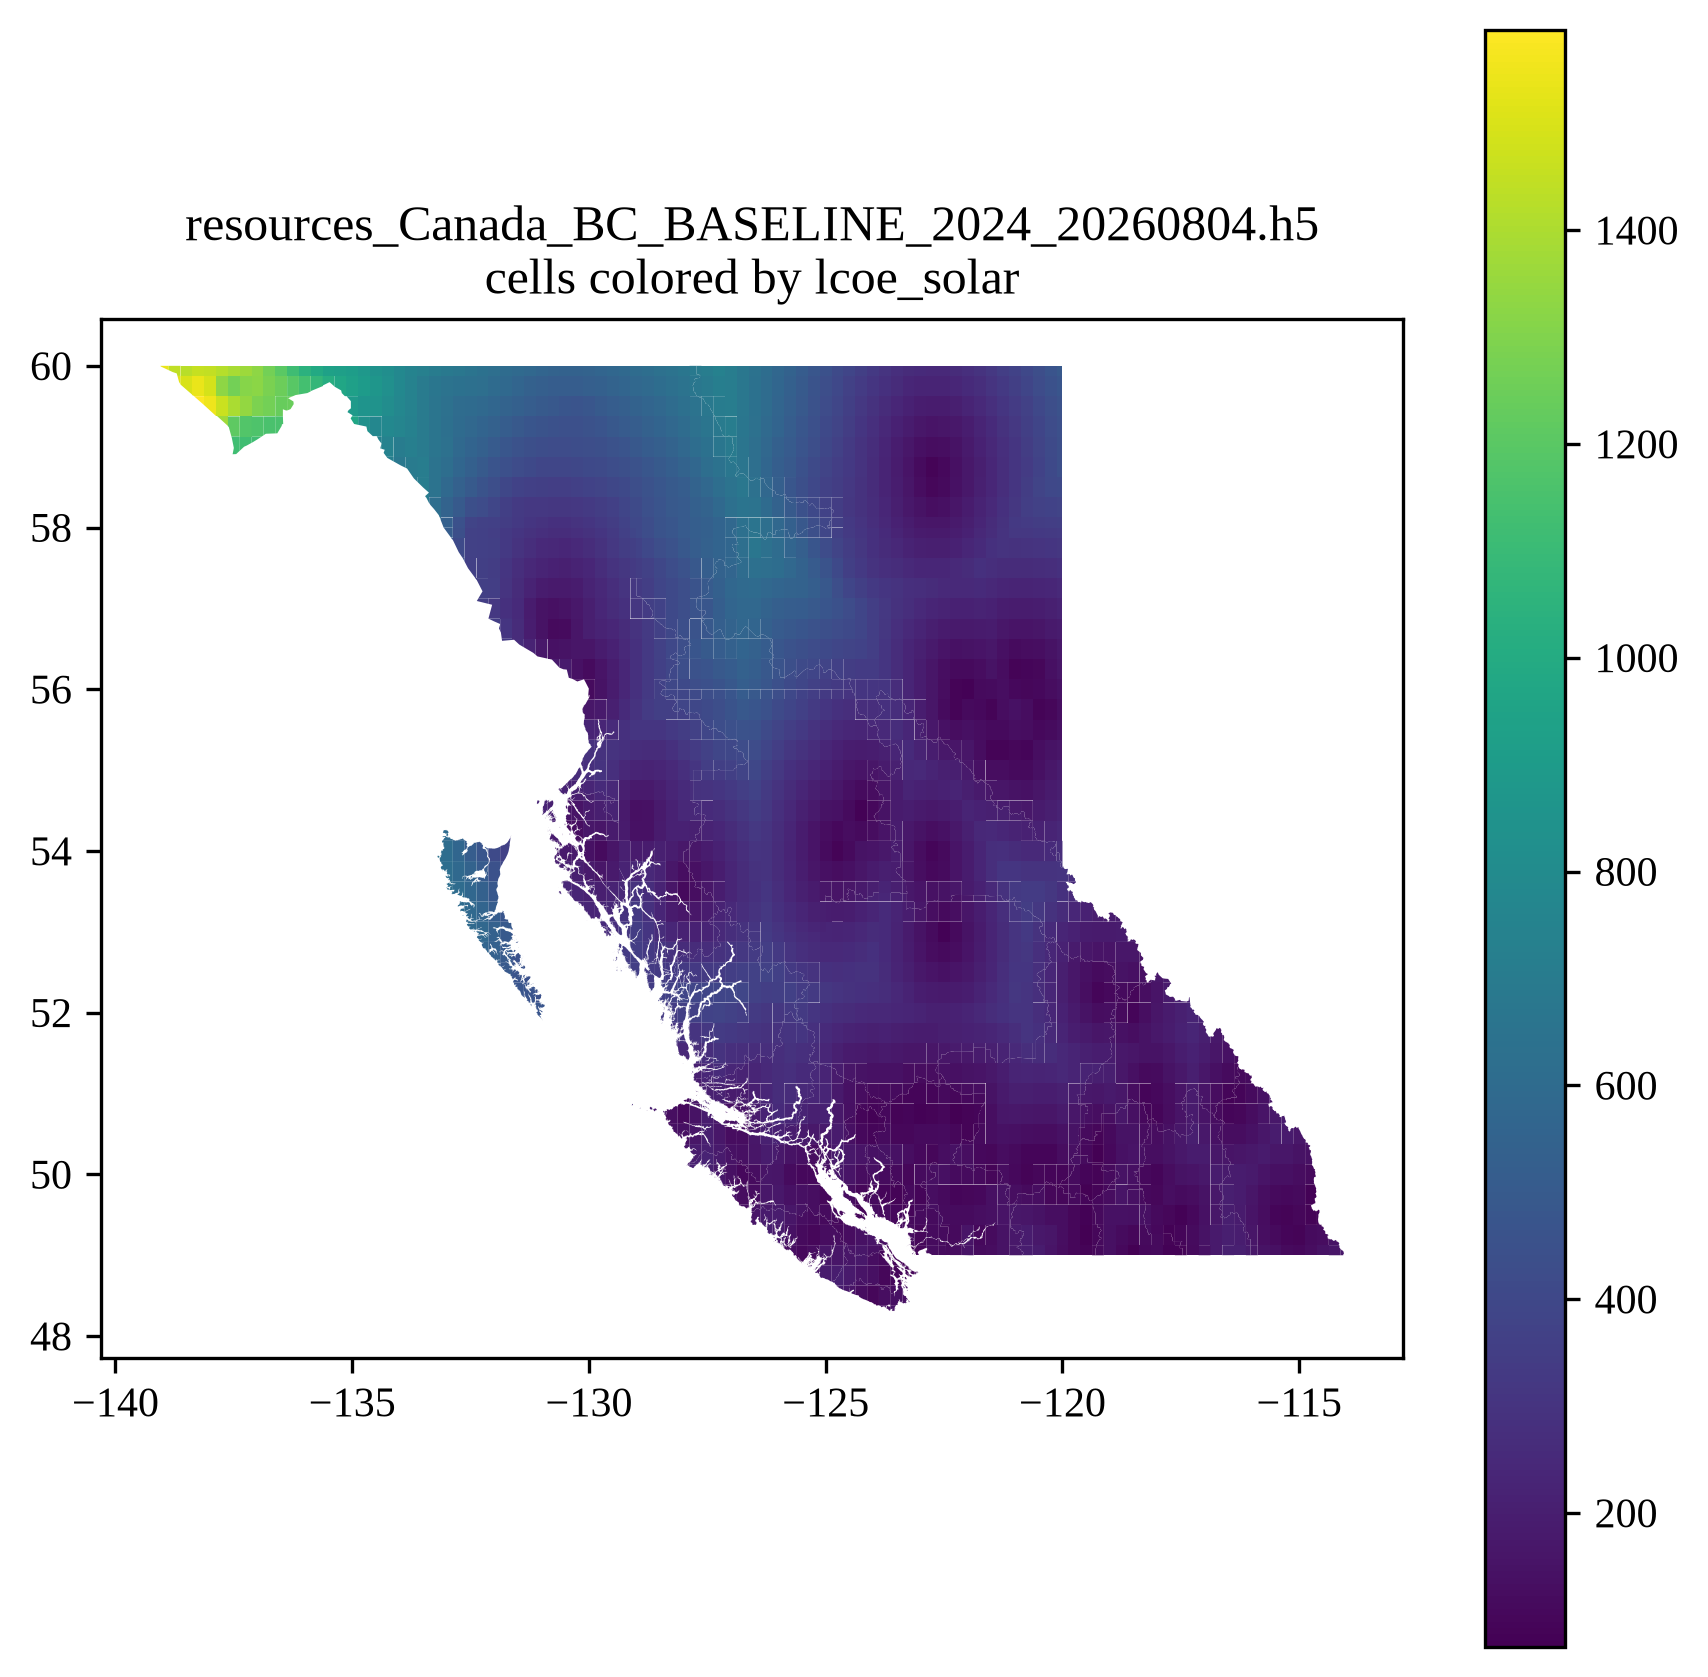

In [8]:
# Map the cells, colored by a numeric column (falls back to a flat plot if no geometry)
fig, ax = plt.subplots(figsize=(7, 7))
color_col = "lcoe_solar" if "lcoe_solar" in cells_df.columns else None
if hasattr(cells_df, "geometry"):
    cells_df.plot(ax=ax, column=color_col, legend=bool(color_col), markersize=3, cmap="viridis")
ax.set_title(f"{store_path.name}\ncells" + (f" colored by {color_col}" if color_col else ""))
plt.show()

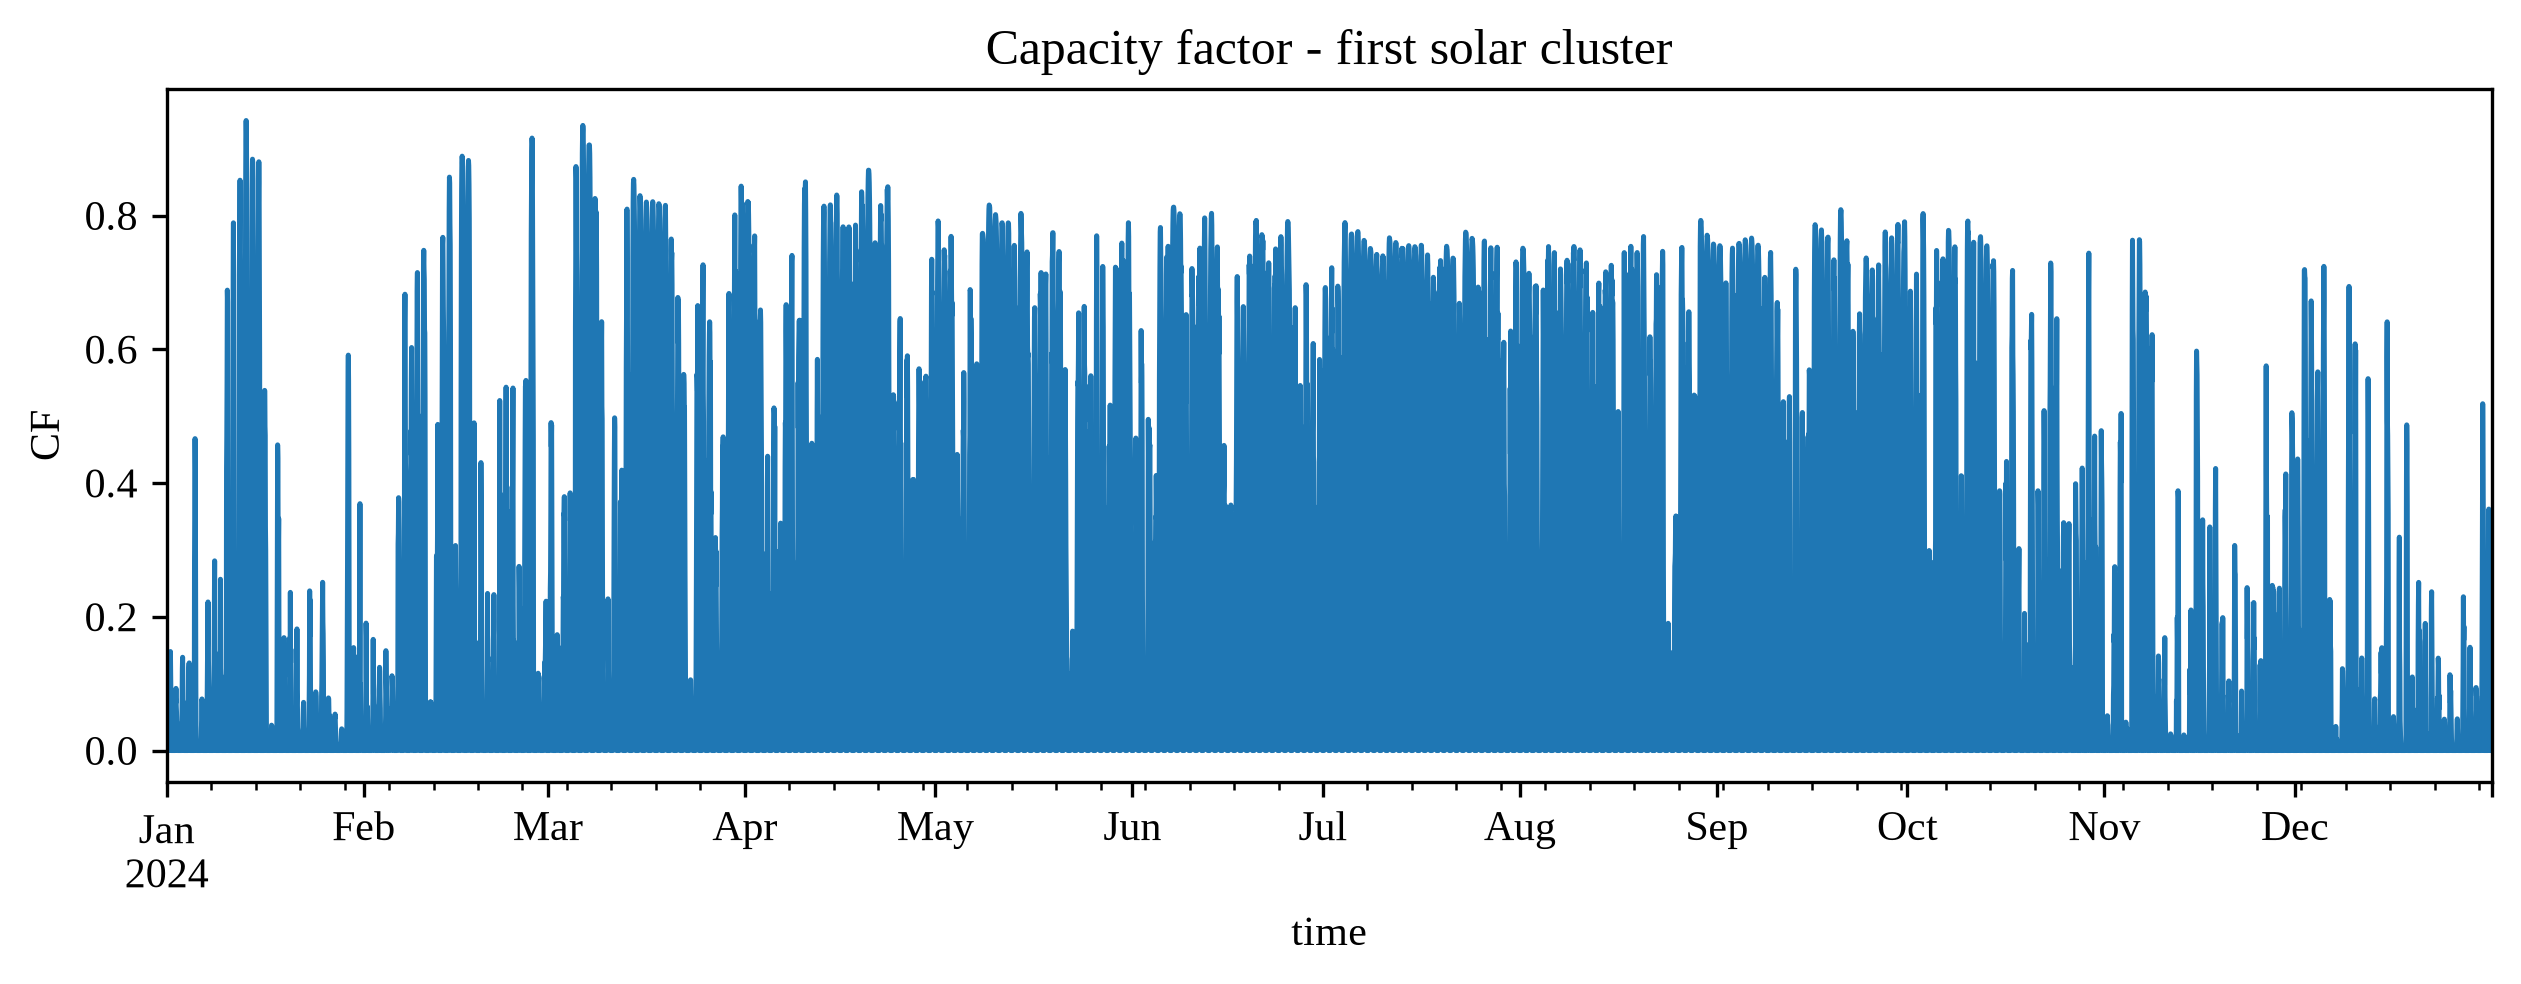

In [9]:
# Load and plot a capacity-factor timeseries for one cluster, if present
try:
    ts_solar = sv.load("timeseries/clusters/solar", decode_geometry=False)
    ts_solar.iloc[:, 0].plot(figsize=(10, 3), title="Capacity factor - first solar cluster")
    plt.ylabel("CF")
    plt.show()
except KeyError as e:
    print(e)

## 5. Export whatever you loaded

Once you have a DataFrame/GeoDataFrame, use the usual pandas/geopandas
export methods for downstream post-processing in QGIS, Excel, etc.

In [ ]:
# cells_df.to_csv("cells_export.csv", index=False)
# cells_df.to_file("cells_export.geojson", driver="GeoJSON")  # geopandas only